In [129]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

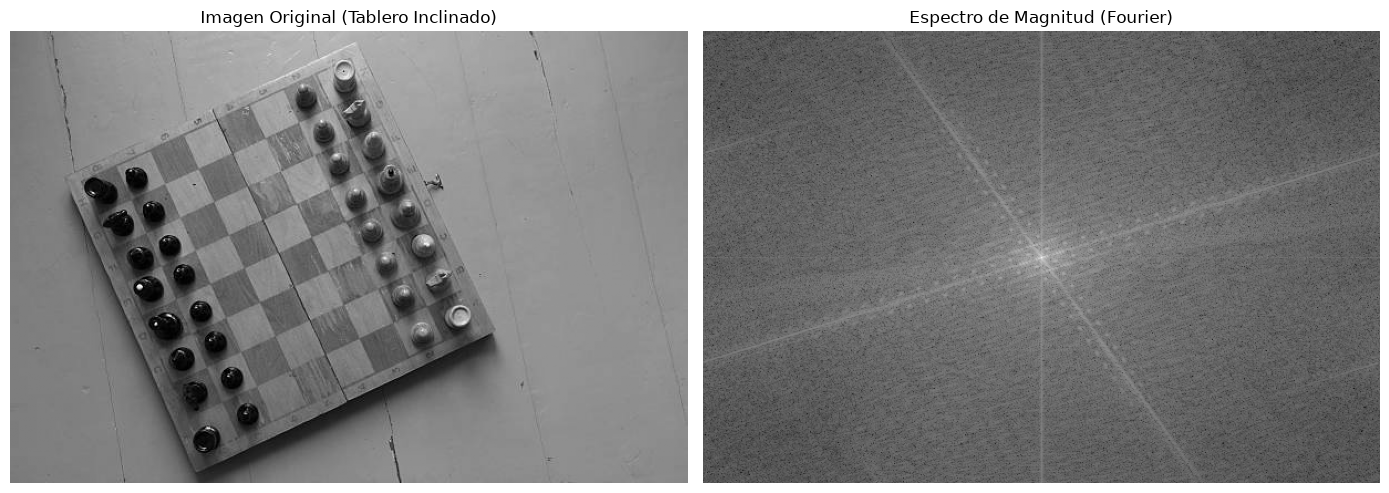

In [130]:

# 1. Cargar la imagen en escala de grises
ruta = "../../data/raw/tablero_inclinado.jpg"
imagen = cv2.imread(ruta, 0)

if imagen is None:
    print("¡Error! No se encontró la imagen 'tablero_inclinado.jpg' en la ruta especificada.")
else:
    # 2. Calcular la Transformada de Fourier Discreta (2D)
    f = np.fft.fft2(imagen)
    
    # 3. Cambiar el componente de frecuencia cero (DC) al centro de la imagen
    # Si no hacemos esto, el centro de las frecuencias quedaría en la esquina superior izquierda.
    fshift = np.fft.fftshift(f)
    
    # 4. Calcular la magnitud del espectro
    # Usamos la escala logarítmica log(1 + |fshift|) para comprimir el rango dinámico y que sea visible
    espectro_magnitud = 20 * np.log(np.abs(fshift) + 1)
    espectro_8u = np.uint8(cv2.normalize(espectro_magnitud, None, 0, 255, cv2.NORM_MINMAX))
    # 5. Mostrar los resultados lado a lado
    fig, axs = plt.subplots(1, 2, figsize=(14, 7))
    
    # Imagen Original
    axs[0].imshow(imagen, cmap='gray')
    axs[0].set_title('Imagen Original (Tablero Inclinado)')
    axs[0].axis('off')
    
    # Espectro de Fourier
    axs[1].imshow(espectro_magnitud, cmap='gray')
    axs[1].set_title('Espectro de Magnitud (Fourier)')
    axs[1].axis('off')
    
    plt.tight_layout()
    plt.show()

Vamos a rotarlo

In [131]:

# 1. Preparar el espectro (Binarización para Hough)
espectro_8u = np.uint8(cv2.normalize(espectro_magnitud, None, 0, 255, cv2.NORM_MINMAX))
umbral_dinamico = np.percentile(espectro_8u, 99.5)
_, espectro_binario = cv2.threshold(espectro_8u, umbral_dinamico, 255, cv2.THRESH_BINARY)

# 2. Aplicar la Transformada de Hough de Líneas
# rho = 1 píxel, theta = 1 grado (en radianes), threshold = 50 votos
lineas = cv2.HoughLines(espectro_binario, 1, np.pi / 180, 55)
# 3. Imprimir los resultados
if lineas is not None:
    print(f"Se detectaron {len(lineas)} líneas en el espectro.")
    for i, linea in enumerate(lineas[:10]):  # Muestra las primeras 10 líneas
        rho, theta = linea[0]
        grado = np.degrees(theta)
        print(f"Línea {i+1}: rho = {rho:.2f}, theta(rad) = {theta:.2f}, ángulo = {grado:.2f}°")
else:
    print("No se detectaron líneas con los parámetros actuales.")


Se detectaron 12 líneas en el espectro.
Línea 1: rho = 285.00, theta(rad) = 1.27, ángulo = 73.00°
Línea 2: rho = 288.00, theta(rad) = 1.26, ángulo = 72.00°
Línea 3: rho = 280.00, theta(rad) = 1.29, ángulo = 74.00°
Línea 4: rho = 294.00, theta(rad) = 1.24, ángulo = 71.00°
Línea 5: rho = 278.00, theta(rad) = 1.31, ángulo = 75.00°
Línea 6: rho = 291.00, theta(rad) = 1.24, ángulo = 71.00°
Línea 7: rho = 271.00, theta(rad) = 1.33, ángulo = 76.00°
Línea 8: rho = -128.00, theta(rad) = 2.51, ángulo = 144.00°
Línea 9: rho = 298.00, theta(rad) = 1.22, ángulo = 70.00°
Línea 10: rho = 275.00, theta(rad) = 1.31, ángulo = 75.00°


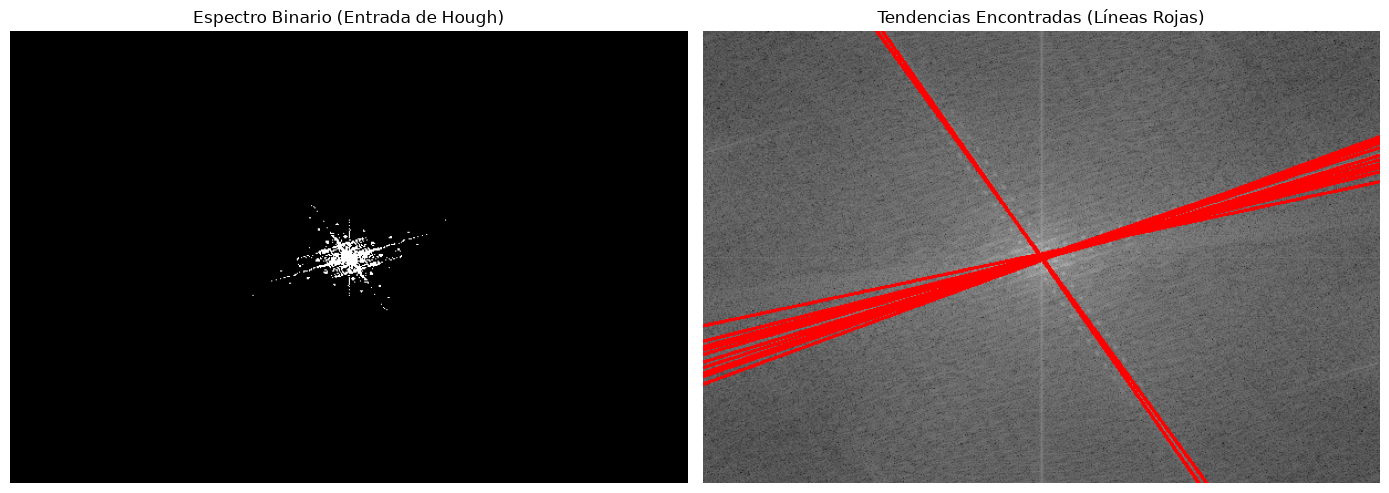

In [132]:
# 1. Crear una copia del espectro para dibujar las líneas encima
espectro_lineas = cv2.cvtColor(espectro_8u, cv2.COLOR_GRAY2RGB)

# 2. Dibujar las líneas encontradas por Hough sobre el espectro
if lineas is not None:
    for linea in lineas:
        rho, theta = linea[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        # Extender la línea para que cruce toda la imagen
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        
        cv2.line(espectro_lineas, (x1, y1), (x2, y2), (255, 0, 0), 2)

# 3. Mostrar el espectro binario al lado del espectro con las líneas marcadas
fig, axs = plt.subplots(1, 2, figsize=(14, 7))

axs[0].imshow(espectro_binario, cmap='gray')
axs[0].set_title('Espectro Binario (Entrada de Hough)')
axs[0].axis('off')

axs[1].imshow(espectro_lineas)
axs[1].set_title('Tendencias Encontradas (Líneas Rojas)')
axs[1].axis('off')

plt.tight_layout()
plt.show()

clusterizamos los resultados encontramos en un k-means y los intentamos agrupar en dos numeros distintos (por la rotacion)

In [133]:
from sklearn.cluster import KMeans

# 1. Crear la lista y guardar TODOS los resultados de Hough
lista_resultados = []

if lineas is not None:
    for linea in lineas:
        rho, theta = linea[0]
        grado = np.degrees(theta)
        lista_resultados.append({
            "rho": rho,
            "theta_rad": theta,
            "angulo_grado": grado
        })

        print(grado)

    # 2. Construir la matriz 'datos_completos' para tener los promedios a mano
    datos_completos = np.array([[l["rho"], l["theta_rad"], l["angulo_grado"]] for l in lista_resultados])
    
    # 3. Extraer solo los ángulos para pasárselos a K-Means
    angulos = datos_completos[:, 2].reshape(-1, 1)

    # 4. Ejecutar K-Means para agrupar en 2 tendencias y generar las 'etiquetas'
    kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto').fit(angulos)
    etiquetas = kmeans.labels_
    
    print(f"K-Means finalizado. Se etiquetaron {len(etiquetas)} líneas en 2 grupos.")
else:
    print("No hay líneas detectadas para procesar.")

72.99999
72.0
73.99999
71.0
74.99999
71.0
75.99999
144.0
69.99999
74.99999
78.0
144.99998
K-Means finalizado. Se etiquetaron 12 líneas en 2 grupos.


agrupamos por un algoritmo no supervisado con k-means y rotamos con aquellos grupos que tengan menor desvio.

Clúster 1: Desvío estándar angular = 2.4187°
Clúster 2: Desvío estándar angular = 0.5000°

--- SELECCIÓN DE TENDENCIA MÁS SÓLIDA ---
Clúster seleccionado por estabilidad: Tendencia 2
Ángulo base del clúster: 144.50°
Grados netos a rotar: 35.50°


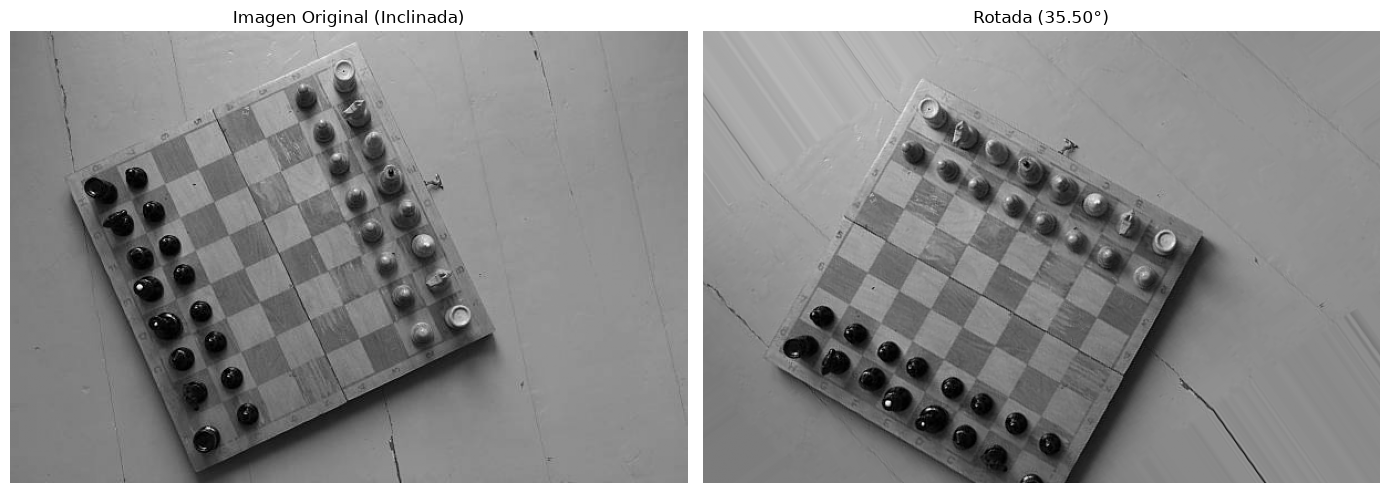

In [134]:
# --- 1. IDENTIFICAR EL CLÚSTER CON MENOR DESVÍO ESTÁNDAR ---
mejor_grupo = None
menor_desvio = float('inf')
angulo_final_tablero = 0.0

for grupo in np.unique(etiquetas):
    # Filtrar índices de las líneas de este grupo
    indices_grupo = np.where(etiquetas == grupo)[0]
    angulos_grupo = datos_completos[indices_grupo, 2]
    
    # Calcular la desviación estándar (desvío) del grupo actual
    desvio_actual = np.std(angulos_grupo)
    print(f"Clúster {grupo + 1}: Desvío estándar angular = {desvio_actual:.4f}°")
    
    # Nos quedamos con el que tenga menor dispersión
    if desvio_actual < menor_desvio:
        menor_desvio = desvio_actual
        mejor_grupo = grupo
        # Guardamos su ángulo promedio
        angulo_final_tablero = np.mean(angulos_grupo)

print("\n--- SELECCIÓN DE TENDENCIA MÁS SÓLIDA ---")
print(f"Clúster seleccionado por estabilidad: Tendencia {mejor_grupo + 1}")
print(f"Ángulo base del clúster: {angulo_final_tablero:.2f}°")

# --- 2. CALCULAR LOS GRADOS DE ROTACIÓN REALES ---
# Calculamos la distancia angular al eje puro más cercano (0°, 90° o 180°)
desviacion_vertical = abs(90.0 - angulo_final_tablero)
desviacion_horizontal_0 = abs(0.0 - angulo_final_tablero)
desviacion_horizontal_180 = abs(180.0 - angulo_final_tablero)

# Nos quedamos con los grados mínimos necesarios para enderezar
grados_rotacion = min(desviacion_vertical, desviacion_horizontal_0, desviacion_horizontal_180)
print(f"Grados netos a rotar: {grados_rotacion:.2f}°")

# --- 3. ROTAR LA IMAGEN ORIGINAL ---
(h, w) = imagen.shape[:2]
centro = (w // 2, h // 2)

# Generamos la matriz de transformación y aplicamos el giro
M = cv2.getRotationMatrix2D(centro, grados_rotacion, 1.0)
imagen_rotada = cv2.warpAffine(imagen, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

# --- 4. MOSTRAR EL RESULTADO DE LA ROTACIÓN ---
fig, axs = plt.subplots(1, 2, figsize=(14, 7))

axs[0].imshow(imagen, cmap='gray')
axs[0].set_title('Imagen Original (Inclinada)')
axs[0].axis('off')

axs[1].imshow(imagen_rotada, cmap='gray')
axs[1].set_title(f'Rotada ({grados_rotacion:.2f}°)')
axs[1].axis('off')

plt.tight_layout()
plt.show()

ahroa vemos si con la rotacion identifica el rectangulo

¡Éxito! Se detectó el recuadro exterior del tablero.


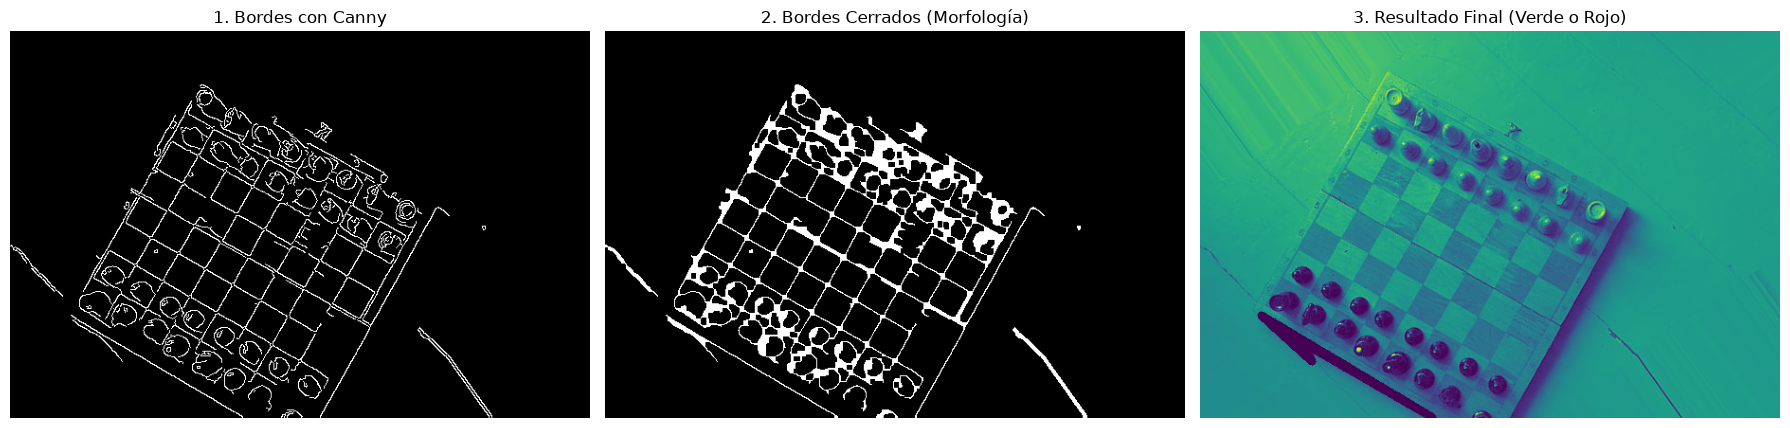

In [135]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

if imagen_rotada is None:
    print("No se pudo cargar la imagen. Revisa la ruta.")
else:
    # 2. SUAVIZADO: Eliminamos imperfecciones o texturas sutiles
    desenfocado = cv2.GaussianBlur(imagen_rotada, (5, 5), 0)
    
    # 3. CANNY (REALCE DE BORDES): Busca cambios bruscos de intensidad.
    # Los valores 50 y 150 son los umbrales de sensibilidad.
    bordes_canny = cv2.Canny(desenfocado, 50, 150)
    
    # 4. OPERACIÓN MORFOLÓGICA (CIERRE): Creamos un "bloque" de 5x5 píxeles
    # para conectar líneas del borde exterior que hayan quedado separadas o rotas.
    kernel = np.ones((5, 5), np.uint8)
    bordes_cerrados = cv2.morphologyEx(bordes_canny, cv2.MORPH_CLOSE, kernel)
    
    # 5. ENCONTRAR CONTORNOS: Buscamos solo el contorno más externo
    contornos, _ = cv2.findContours(bordes_cerrados, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Ordenamos por tamaño (área) de mayor a menor
    contornos = sorted(contornos, key=cv2.contourArea, reverse=True)
    
    tablero_esquinas = None
    
    # 6. FILTRAR POR RECTÁNGULO: Buscamos cuál de los contornos grandes tiene 4 esquinas
    for c in contornos:
        perimetro = cv2.arcLength(c, True)
        aproximacion = cv2.approxPolyDP(c, 0.02 * perimetro, True)
        
        if len(aproximacion) == 4:
            tablero_esquinas = aproximacion
            break
            
    # 7. DIBUJAR Y MOSTRAR TODO EL PROCESO
    if tablero_esquinas is not None:
        print("¡Éxito! Se detectó el recuadro exterior del tablero.")
        cv2.drawContours(imagen_rotada, [tablero_esquinas], -1, (0, 255, 0), 7)
    else:
        print("No se encontró un contorno exterior de 4 esquinas perfecto.")
        print("Intentaremos dibujar el contorno más grande que encontró (tenga o no 4 esquinas) para ver qué pasó:")
        if len(contornos) > 0:
            cv2.drawContours(imagen_rotada, [contornos[0]], -1, (255, 0, 0), 5)

    # Bloque de visualización en Jupyter para diagnóstico
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    
    axs[0].imshow(bordes_canny, cmap='gray')
    axs[0].set_title("1. Bordes con Canny")
    axs[0].axis('off')
    
    axs[1].imshow(bordes_cerrados, cmap='gray')
    axs[1].set_title("2. Bordes Cerrados (Morfología)")
    axs[1].axis('off')
    
    axs[2].imshow(imagen_rotada)
    axs[2].set_title("3. Resultado Final (Verde o Rojo)")
    axs[2].axis('off')
    
    plt.tight_layout()
    plt.show()